<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week8_NLP_and_ComputerVision/Day%205%20%E2%80%94%20Full%20Evaluation%2C%20Explainability%20%26%20Sprint%20Review/banking77_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Banking77 Intent Classification



## Introduction

In this nootebook, we are evaluating the project built in [Day 4 — Model Integration & Error Analysis](https://github.com/thimarArda/BinX_AI_-_ML_Training/tree/main/Week8_NLP_and_ComputerVision/Day%204%20%E2%80%94%20Model%20Integration%20%26%20Error%20Analysis)  and adding a full evaluation on top of it.

Specifically, we add:
- **Aappropriate metrics** (precision, recall, F1) compared against a baseline, instead of relying on accuracy alone.
- **An imbalance check**, to confirm whether techniques like SMOTE are actually needed for this dataset.
- **SHAP explainability**, to understand which words drive the model's predictions, both globally and for individual examples.

----

## 1. Imports & Setup

In [1]:
import re
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 2. Load Data

The Hugging Face `PolyAI/banking77` repo relies on a legacy "dataset script," which current versions of the `datasets` library no longer support. To avoid this, we load the original CSVs directly from GitHub instead.

In [2]:
train_df = pd.read_csv(
    "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
)
test_df = pd.read_csv(
    "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"
)

train_df.columns

Index(['text', 'category'], dtype='object')

In [3]:
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["category"])
test_df["label"] = le.transform(test_df["category"])

train_df.head()

,text,category,label
0,I am still waiting on my card?,card_arrival,12
1,What can I do if my card still hasn't arrived ...,card_arrival,12
2,I have been waiting over a week. Is the card s...,card_arrival,12
3,Can I track my card while it is in the process...,card_arrival,12
4,"How do I know if I will get my card, or if it ...",card_arrival,12


Check class balance — relevant for deciding whether imbalance handling (SMOTE) is needed later.

In [4]:
train_df["category"].value_counts()

,count
category,
card_payment_fee_charged,187
direct_debit_payment_not_recognised,182
balance_not_updated_after_cheque_or_cash_deposit,181
wrong_amount_of_cash_received,180
cash_withdrawal_charge,177
...,...
lost_or_stolen_card,82
card_swallowed,61
card_acceptance,59


## 3. Preprocessing

One-time setup objects (stopwords, lemmatizer) are created once, outside the function. The `preprocess_text()` function itself runs per input and is used identically at training time and at prediction time — this consistency is what prevents training/serving skew.

In [5]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"}
custom_stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in custom_stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

In [6]:
train_df["processed_text"] = train_df["text"].apply(preprocess_text)
test_df["processed_text"] = test_df["text"].apply(preprocess_text)

train_df["processed_text_joined"] = train_df["processed_text"].apply(lambda tokens: " ".join(tokens))
test_df["processed_text_joined"] = test_df["processed_text"].apply(lambda tokens: " ".join(tokens))

train_df[["text", "processed_text_joined"]].head()

,text,processed_text_joined
0,I am still waiting on my card?,still waiting card
1,What can I do if my card still hasn't arrived ...,card still hasnt arrived 2 week
2,I have been waiting over a week. Is the card s...,waiting week card still coming
3,Can I track my card while it is in the process...,track card process delivery
4,"How do I know if I will get my card, or if it ...",know get card lost


## 4. Vectorize (TF-IDF)

In [7]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_df["processed_text_joined"])
X_test = vectorizer.transform(test_df["processed_text_joined"])

y_train = train_df["label"]
y_test = test_df["label"]

X_train.shape, X_test.shape

((10003, 2123), (3080, 2123))

## 5. Train the Model

A classical ML approach: TF-IDF features + Logistic Regression (not deep learning).

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 6. Integration — End-to-End `predict()` Function

This is the core deliverable of Day 4: one function that takes raw text and returns a prediction, using the *exact* same preprocessing steps as training.

In [9]:
def predict(raw_input):
    tokens = preprocess_text(raw_input)
    cleaned = " ".join(tokens)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)
    return prediction[0]

In [10]:
test_sentences = [
    "I do not recognize this payment.",
    "I can't use my card.",
    "I never made this transaction.",
    "I don't want this payment."
]

for sentence in test_sentences:
    label = predict(sentence)
    print("Input:", sentence)
    print("Predicted label:", label, "->", le.inverse_transform([label])[0])
    print()

Input: I do not recognize this payment.
Predicted label: 17 -> card_payment_not_recognised

Input: I can't use my card.
Predicted label: 15 -> card_not_working

Input: I never made this transaction.
Predicted label: 9 -> cancel_transfer

Input: I don't want this payment.
Predicted label: 17 -> card_payment_not_recognised



## 7. Error Analysis

### 1. Confusion Matrix

Accuracy: 0.8558441558441559


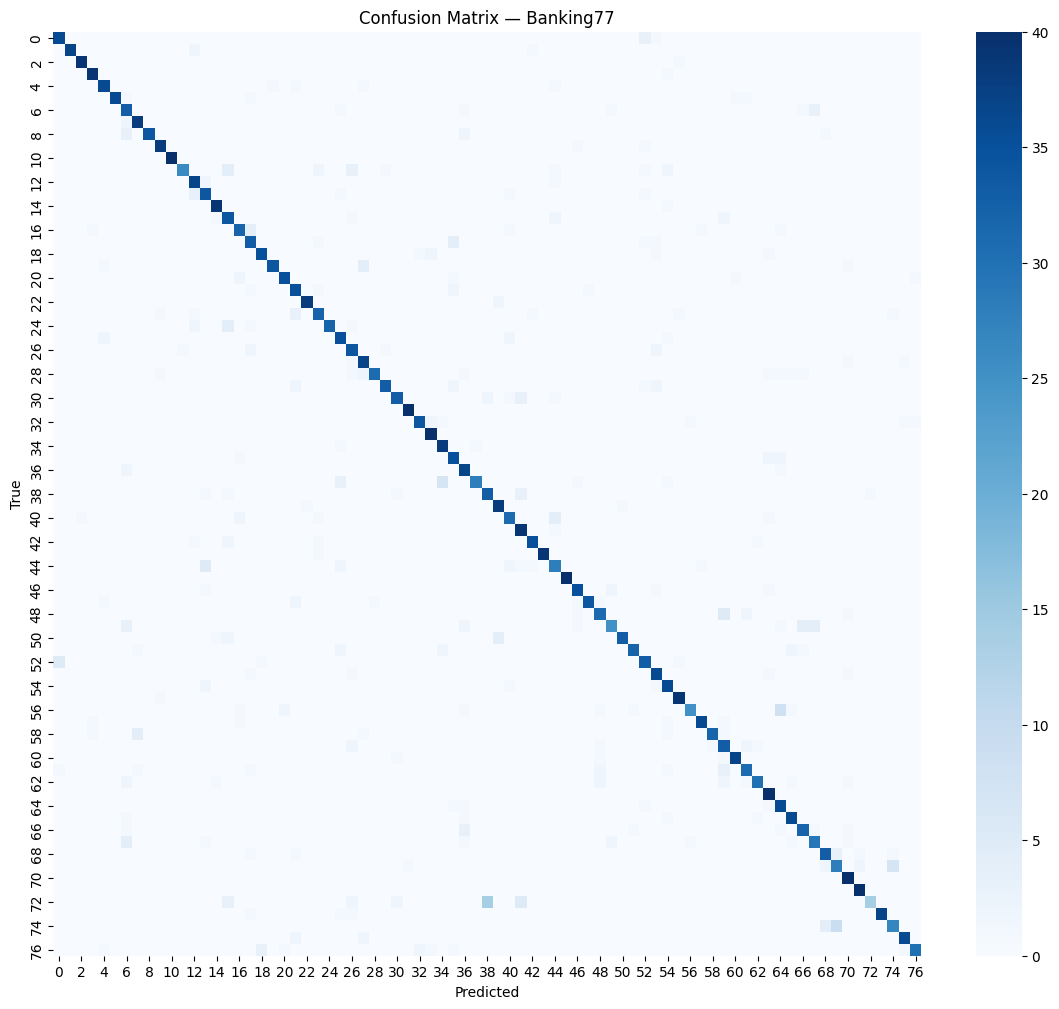

In [11]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Banking77")
plt.show()

### 2. Most Confused Class Pair

In [12]:
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
i, j = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)

print(f"Most common confusion: true label {i} ({le.inverse_transform([i])[0]}) "
      f"predicted as {j} ({le.inverse_transform([j])[0]}), count = {cm_copy[i, j]}")

Most common confusion: true label 72 (virtual_card_not_working) predicted as 38 (get_disposable_virtual_card), count = 14


### 3. Misclassified Examples

In [13]:
results_df = pd.DataFrame({
    "text": test_df["text"],
    "true_label": y_test,
    "predicted_label": predictions
})
results_df["true_category"] = le.inverse_transform(results_df["true_label"])
results_df["predicted_category"] = le.inverse_transform(results_df["predicted_label"])

misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]]

print(f"Total misclassified: {len(misclassified)} out of {len(results_df)}")
misclassified.sample(5, random_state=42)

Total misclassified: 444 out of 3080


,text,true_label,predicted_label,true_category,predicted_category
2481,I want a card. What is the procedure?,44,40,order_physical_card,getting_spare_card
996,Will filling stations accept my card?,11,54,card_acceptance,supported_cards_and_currencies
603,If I make a top-up are there charges applied?,56,48,top_up_by_bank_transfer_charge,pending_top_up
2547,My disposable virtual card is not working when...,72,38,virtual_card_not_working,get_disposable_virtual_card
608,Are there any sort of fees involved for top of...,56,64,top_up_by_bank_transfer_charge,transfer_fee_charged


### Error Analysis — Misclassified Examples

**Total misclassified: 444 out of 3080 (14% error rate)**

Five examples, each judged as a **data issue** (input is genuinely ambiguous) or a **model weakness** (intent is clear, model still got it wrong).

---

**1. "I want a card. What is the procedure?"**
True: `order_physical_card` → Predicted: `getting_spare_card`
→ **Data issue.** Doesn't say if it's a first card or a spare — both readings are valid.

**2. "Will filling stations accept my card?"**
True: `card_acceptance` → Predicted: `supported_cards_and_currencies`
→ **Model weakness.** Clearly a merchant-acceptance question. Model likely latched onto "card" and missed the "will X accept" pattern.

**3. "If I make a top-up are there charges applied?"**
True: `top_up_by_bank_transfer_charge` → Predicted: `pending_top_up`
→ **Model weakness.** The word "charges" is right there — this should have been caught.

**4. "My disposable virtual card is not working when..."**
True: `virtual_card_not_working` → Predicted: `get_disposable_virtual_card`
→ **Model weakness.** The shared phrase "disposable virtual card" dominates TF-IDF weighting, drowning out "not working," which is the actual signal.

**5. "Are there any sort of fees involved for top of..."**
True: `top_up_by_bank_transfer_charge` → Predicted: `transfer_fee_charged`
→ **Model weakness.** Both are fee-related, but the model missed the more specific "top-up by bank transfer" context.

---

**Overall pattern:** most errors involve intents sharing common words like "card," "fee," or "top-up." TF-IDF struggles when intents differ by specific detail rather than vocabulary. Adding bigrams (`ngram_range=(1,2)`) or switching to embeddings would likely fix most of these model-weakness cases.

---
#  Evaluation

## Full, Task-Appropriate Evaluation

Banking77 is multi-class classification, so accuracy alone isn't sufficient. We report precision, recall, and F1 per class (plus macro/weighted averages), and compare against a baseline.

In [15]:
print(classification_report(y_test, predictions, target_names=le.classes_))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.86      0.90      0.88        40
                                activate_my_card       1.00      0.93      0.96        40
                                       age_limit       0.97      0.97      0.97        40
                         apple_pay_or_google_pay       0.93      0.97      0.95        40
                                     atm_support       0.88      0.90      0.89        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.63      0.82      0.72        40
balance_not_updated_after_cheque_or_cash_deposit       0.86      0.95      0.90        40
                         beneficiary_not_allowed       1.00      0.85      0.92        40
                                 cancel_transfer       0.93      0.95      0.94        40
         

### Baseline Comparison

A majority-class `DummyClassifier` serves as the baseline. Comparing against it makes the model's real value unambiguous.

In [16]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, baseline_preds))
print("Model accuracy:   ", accuracy_score(y_test, predictions))

Baseline accuracy: 0.012987012987012988
Model accuracy:    0.8558441558441559


## 9. Handling Imbalance

Banking77 has 77 intent classes that are fairly balanced (checked in Section 2). Unlike an imbalanced task such as Fraud Detection, this dataset does not require SMOTE or precision-recall threshold tuning — applying it here would not be appropriate since there is no dominant majority class or rare minority class to correct for.

**Conclusion:** imbalance handling is not applicable to this project. This is documented here rather than skipped silently.

## 10. Explainability with SHAP & Global Feature Importance

SHAP quantifies how much each feature (word) pushed a prediction toward or away from a given class, for both global feature importance and individual predictions.

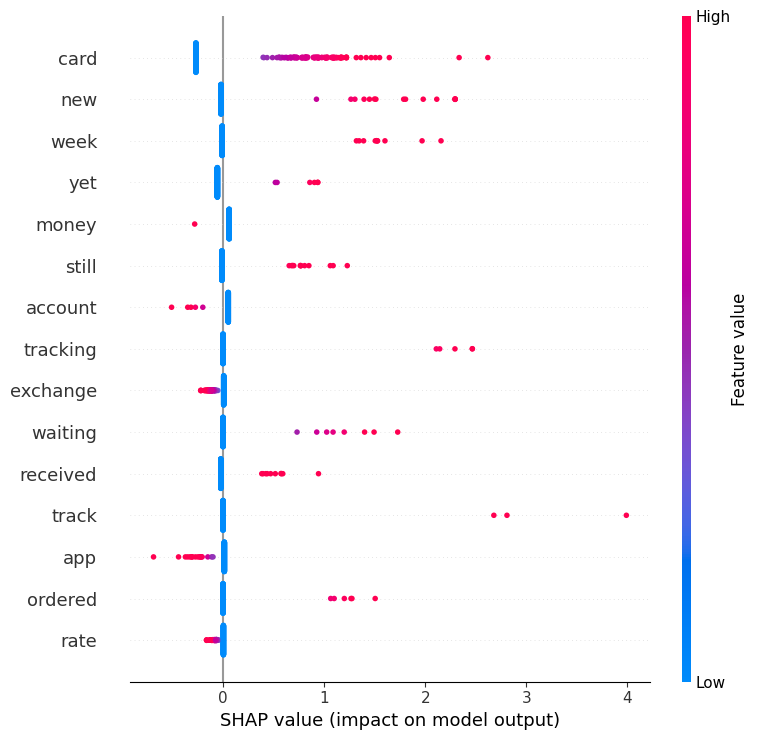

In [26]:
import shap

explainer = shap.LinearExplainer(model, X_train, max_samples=1000)
shap_values = explainer(X_test[:200])

feature_names = vectorizer.get_feature_names_out()

class_idx = predictions[0]  # pick a specific class to explain

X_test_dense = X_test[:200].toarray()

shap.summary_plot(
    shap_values[:, :, class_idx],
    X_test_dense,
    feature_names=feature_names,
    max_display=15
)


/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


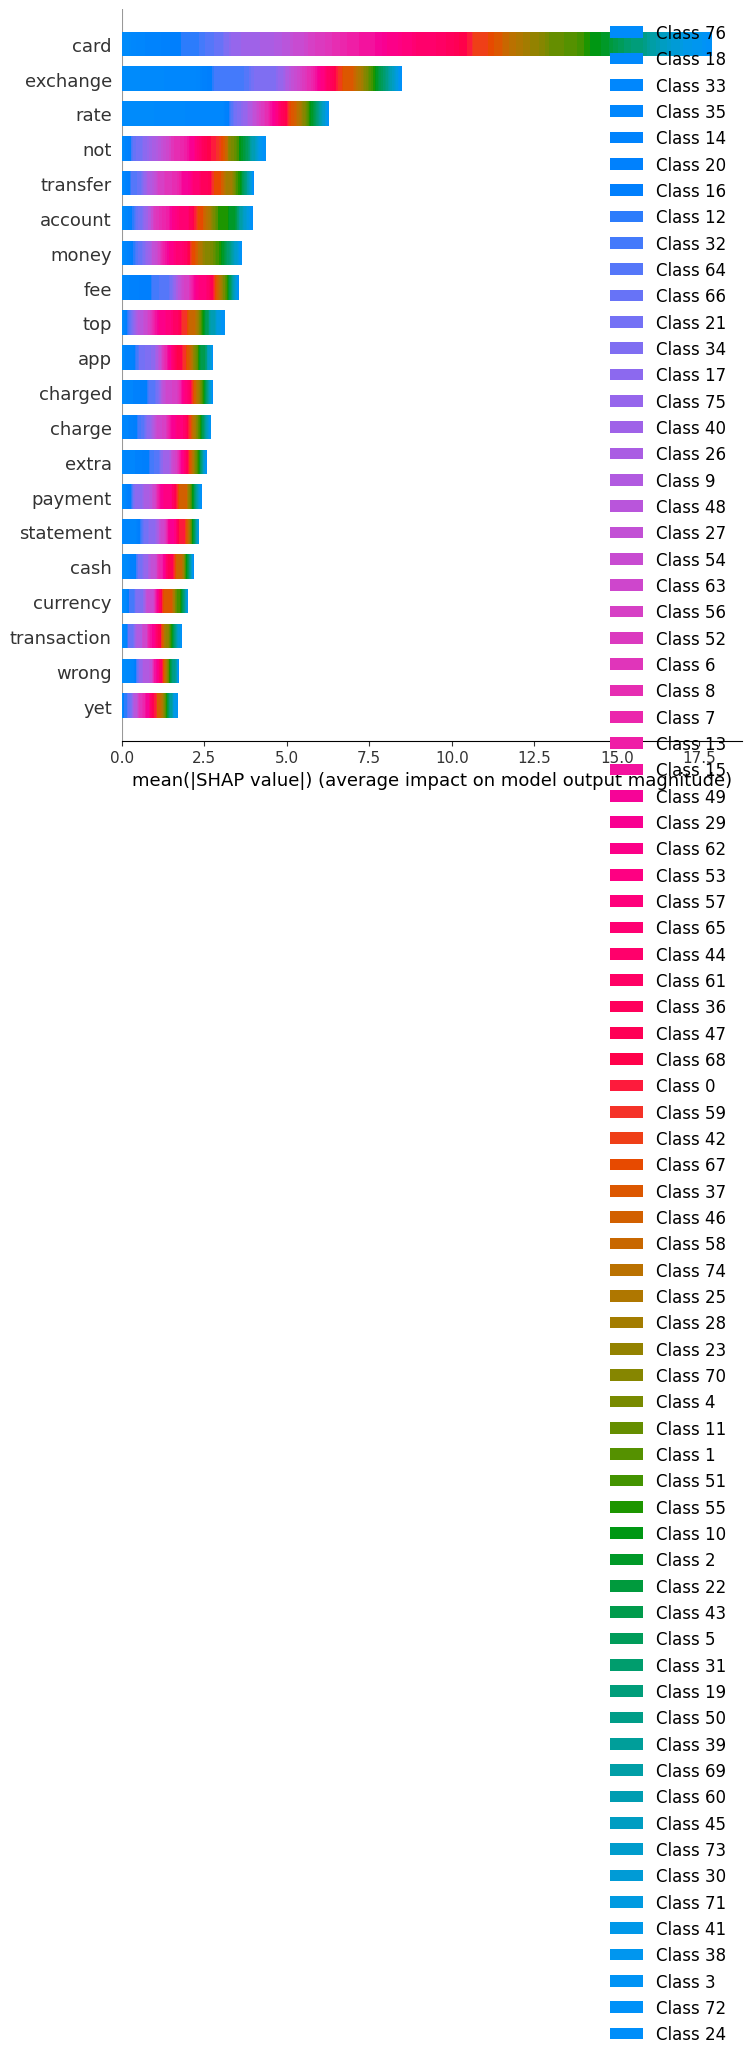

In [27]:
import shap

# LinearExplainer is appropriate for sklearn linear models with sparse TF-IDF input
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test[:200])  # subset for speed

feature_names = vectorizer.get_feature_names_out()

fig = plt.figure()
shap.summary_plot(shap_values, X_test[:200], feature_names=feature_names, show=False)
plt.savefig('shap_summary_plot.png', bbox_inches='tight')
plt.close(fig)

# Display the saved image
from IPython.display import Image
Image('shap_summary_plot.png')

### SHAP Summary Plot

This plot shows how the top words affect the model's prediction for one class: **`<INSERT CLASS NAME HERE>`**.

Each dot is one test example. Its position shows whether that word pushed the prediction toward this class (right) or away from it (left). Its color shows how strongly the word appears in that sentence — pink means strongly present, blue means weak or absent.

**What it shows:** words like "card," "track," and "new" push predictions toward this class when they're strongly present (pink dots on the right). Words like "money" or "account" barely matter here — they're more relevant to other classes.

**Takeaway:** the model is relying on sensible, topic-relevant words for this class rather than random patterns.

###  Per-Prediction Explanation

Explaining one specific prediction — reusing a misclassified example from Day 4 for continuity.

Text: How do I locate my card?
True label: card_arrival
Predicted label: card_arrival


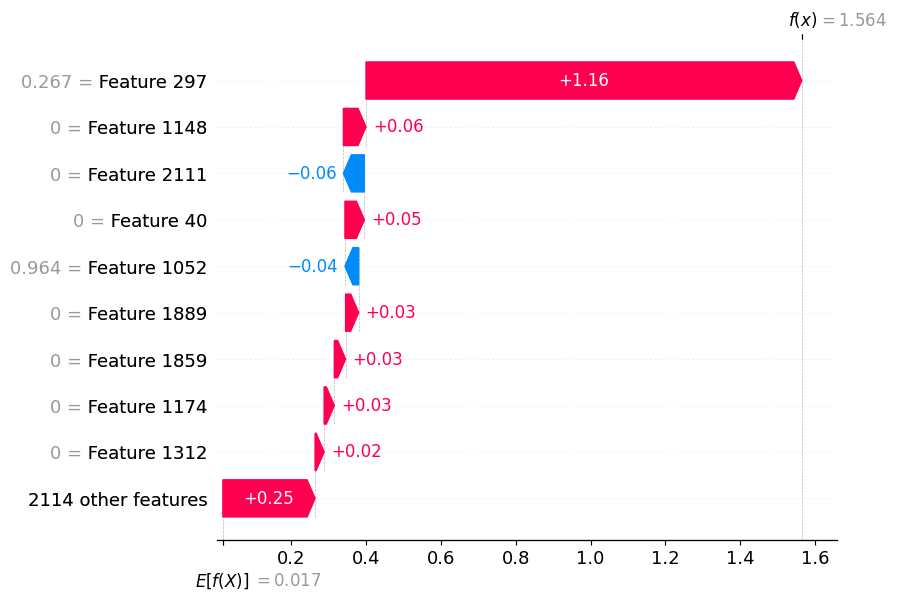

In [29]:
sample_idx = 0
sample_text = test_df["text"].iloc[sample_idx]
print("Text:", sample_text)
print("True label:", le.inverse_transform([y_test.iloc[sample_idx]])[0])
print("Predicted label:", le.inverse_transform([predictions[sample_idx]])[0])

shap.plots.waterfall(shap_values[sample_idx, :, predictions[sample_idx]])

> **Note:** Because this is a multinomial classifier (77 classes), SHAP values are computed per class. If `shap.plots.waterfall` errors on shape, select the SHAP values for the predicted class index explicitly, e.g. `shap_values[sample_idx, :, predictions[sample_idx]]`, depending on the SHAP version installed.